# Task 3: Time Series Prediction using LSTM on the AgriWebb dataset

In [1]:
#pip install kmodes

In [1]:
import pandas as pd
sample_paddock_data= pd.read_csv("tsdm.csv")

In [2]:
# correcting the data types according to the varaible description table

sample_paddock_data["PADDOCK_ID"] = sample_paddock_data["PADDOCK_ID"].astype("string")

In [3]:
# converting a column with date as data type

sample_paddock_data["OBSERVATION_DATE"] = pd.to_datetime(sample_paddock_data["OBSERVATION_DATE"])

In [4]:
# sorting all the data with Paddock id first and then the observation date

sample_paddock_data = sample_paddock_data.sort_values(['PADDOCK_ID', 'OBSERVATION_DATE']).reset_index(drop=True)


In [5]:
# removing paddock ids with shorter sequence

seq_len = sample_paddock_data.groupby("PADDOCK_ID").size().rename("sequence_length")
max_len = int(seq_len.max())
valid_paddocks = seq_len[seq_len == max_len].index

before = sample_paddock_data["PADDOCK_ID"].nunique()
sample_paddock_data = sample_paddock_data[sample_paddock_data["PADDOCK_ID"].isin(valid_paddocks)].reset_index(drop=True)
after = sample_paddock_data["PADDOCK_ID"].nunique()

print(f"Total paddocks before filteration: {before}")
print(f"Paddocks removed: {before - after}")
print(f"Paddocks after filteration: {after}")

sample_paddock_data = sample_paddock_data[sample_paddock_data["PADDOCK_ID"].isin(valid_paddocks)].reset_index(drop=True)

Total paddocks before filteration: 19
Paddocks removed: 7
Paddocks after filteration: 12


In [6]:
sample_paddock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   PADDOCK_ID          2340 non-null   string        
 1   OBSERVATION_DATE    2340 non-null   datetime64[ns]
 2   TSDM                2340 non-null   float64       
 3   15D_AVG_DAILY_RAIN  2340 non-null   float64       
 4   15D_AVG_MAX_TEMP    2340 non-null   float64       
 5   15D_AVG_MIN_TEMP    2340 non-null   float64       
 6   15D_AVG_RH_TMAX     2340 non-null   float64       
 7   15D_AVG_RH_TMIN     2340 non-null   float64       
 8   15D_AVG_EVAP_SYN    2340 non-null   float64       
 9   15D_AVG_RADIATION   2340 non-null   float64       
dtypes: datetime64[ns](1), float64(8), string(1)
memory usage: 182.9 KB


In [7]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence

def create_sequences(sequence, lookback, forecast_horizon, target_col, pad_value=0.0):
    T, num_features = sequence.shape
    X, y, lengths = [], [], []

    if lookback > 0:
        # Fixed-length lookback with pre-padding
        pad_vector = np.zeros((lookback, num_features))

        for t in range(1, T - forecast_horizon + 1):
            context = sequence[:t]
            if len(context) > lookback:
                context = context[-lookback:]

            padded_context = pad_vector.copy()
            padded_context[-len(context):] = context

            X.append(padded_context)
            y.append(sequence[t:t + forecast_horizon, target_col])
            lengths.append(min(len(context), lookback))

        return np.array(X), np.array(y), lengths

    else:
        # Full history with left pre-padding (variable-length inputs)
        for t in range(1, T - forecast_horizon + 1):
            context = torch.tensor(sequence[:t], dtype=torch.float32)
            lengths.append(t)

            X.append(context)  # No manual padding
            y.append(torch.tensor(sequence[t:t + forecast_horizon, target_col], dtype=torch.float32))

        X_padded = pad_sequence(X, batch_first=True, padding_value=pad_value)
        y_tensor = torch.stack(y)

        return X_padded.numpy(), y_tensor.numpy(), lengths

In [8]:
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

def data_prep(df, feature_columns, lookback, test_steps, target_col):
    # Prepare to store all training data
    X_all, y_all = [], []
    paddock_data_ids = []  # To track which paddock each sample comes from
    test_data = []  # To store test data for each paddock
    train_data = []
    lengths_all = []  # To store the lengths of each sequence for packing

    # Fit a global scaler 
    all_train_values = []
    for _, group in df.groupby("PADDOCK_ID"):
        feature_values = group[feature_columns].values
        if len(feature_values) > lookback + test_steps:
            all_train_values.append(feature_values[:-test_steps])
    all_train_values = np.vstack(all_train_values)

    global_scaler = MinMaxScaler()
    global_scaler.fit(all_train_values)
    
    # Process each paddocks's data
    for paddock_id, group in df.groupby('PADDOCK_ID'):
        feature_values = group[feature_columns].values

        # If there are not enough samples for training, skip this location
        if len(feature_values) <= 63:
            continue
            
        # Separate the last 5 steps for testing
        train_sample = global_scaler.transform(feature_values[:-test_steps])
        test_sample = global_scaler.transform(feature_values[-test_steps:])
        
        # If you prefer without scaling
        #train_sample = feature_values[:-test_steps]
        #test_sample = feature_values[-test_steps:]
        
        train_data.append((paddock_id, train_sample))
        test_data.append((paddock_id, test_sample, global_scaler))  # Store test data and scaler

        # Prepare LSTM sequence data for training
        X_paddock, y_paddock, lengths = create_sequences(train_sample, lookback, test_steps, target_col)

        # Append to the overall dataset
        X_all.append(X_paddock)
        y_all.append(y_paddock)
        lengths_all.append(lengths)  # Store sequence lengths

        # Store Location ID for tracking
        paddock_data_ids.extend([paddock_id] * len(y_paddock))

    # Concatenate all locations' training data for model training
    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)
    lengths_all = np.concatenate(lengths_all, axis=0)  # Concatenate sequence lengths

    # Reshape X to be [samples, time steps, features] as required by LSTM
    X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], X_all.shape[2]))  
    
    return torch.Tensor(X_all), torch.Tensor(y_all), torch.Tensor(lengths_all), train_data, test_data


In [9]:
lookback = 5
test_steps = 5
target_col = 0
X_5, y_5, lenghts_5, train_d_5, test_d_5 = data_prep(sample_paddock_data,['TSDM'],lookback,test_steps, target_col)

print("Shape of input data after sequence creation:", X_5.shape)
print("Shape of targets after sequence creation:", y_5.shape)

Shape of input data after sequence creation: torch.Size([2220, 5, 1])
Shape of targets after sequence creation: torch.Size([2220, 5])


In [10]:
# Defining the LSTM network
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class MyLSTMNet(nn.Module):
    def __init__(self, num_features, hidden_layer_size, num_layers, output_size, dropout_prob):
        super().__init__()
        self.lstm = nn.LSTM(input_size=num_features,  
                            hidden_size=hidden_layer_size,
                            num_layers=num_layers,
                            batch_first=True)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_layer_size, output_size)

    def forward(self, data, lengths):
        # Pack the input sequence - This ensures that the LSTM ignores padded values during computation.
        packed_data = pack_padded_sequence(data, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # Run through LSTM
        packed_output, (hn, cn) = self.lstm(packed_data)

        # Use the last layer's hidden state
        last_hidden = hn[-1]  

        # Apply dropout and final linear layer
        out = self.dropout(last_hidden)
        out = self.fc(out)  
        return out


In [11]:
num_features = X_5.shape[2]
hidden_layer_size = 16
output_size = test_steps
num_layers = 1
dropout_prob = 0.2
model_lstm_5 = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)

In [12]:
print(model_lstm_5)

MyLSTMNet(
  (lstm): LSTM(1, 16, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=16, out_features=5, bias=True)
)


In [13]:
# defining the training process

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split

def train_predict_model(model, n_epochs, lr, X_all, y_all, lengths, validation_split=0.2):
    batch_size = 32

    # Split data into train and validation sets
    dataset = TensorDataset(X_all, y_all, lengths)
    val_size = int(len(dataset) * validation_split)
    train_size = len(dataset) - val_size
    train_set, val_set = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print(f"The model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")

    train_loss_history = []
    val_loss_history = []

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch, lengths_batch in train_loader:
            y_pred = model(X_batch, lengths_batch)
            loss = loss_fn(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation check every 100 epochs
        if epoch % 100 == 0:
            model.eval()
            with torch.no_grad():
                train_preds = model(X_all[train_set.indices], lengths[train_set.indices])
                train_loss = loss_fn(train_preds, y_all[train_set.indices]).item()

                val_preds = model(X_all[val_set.indices], lengths[val_set.indices])
                val_loss = loss_fn(val_preds, y_all[val_set.indices]).item()

                print(f"Epoch {epoch+1}: train loss {train_loss:.4f}, val loss {val_loss:.4f}")

                train_loss_history.append(train_loss)
                val_loss_history.append(val_loss)

                # Save best model
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_model_state = model.state_dict()

    # Restore best model state
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_loss_history, val_loss_history, model


In [14]:
n_epochs = 501
lr = 0.001
train_loss_history_5,val_loss_history_5, model_lstm_5 = train_predict_model(model_lstm_5, n_epochs, 
                                                                            lr, X_5, y_5, lenghts_5,
                                                                            validation_split=0.2)

The model has 1,301 trainable parameters
Epoch 1: train loss 0.0264, val loss 0.0274
Epoch 101: train loss 0.0141, val loss 0.0148
Epoch 201: train loss 0.0131, val loss 0.0139
Epoch 301: train loss 0.0128, val loss 0.0137
Epoch 401: train loss 0.0126, val loss 0.0135
Epoch 501: train loss 0.0126, val loss 0.0135


In [15]:
def vis_train_loss(train_loss_history, val_loss_history):
    epochs = range(0, n_epochs, 100) 
    plt.plot(epochs, train_loss_history, label='Training Loss')
    plt.plot(epochs, val_loss_history, label='Validation Loss')  # <-- add this line
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Convergence')
    plt.legend()
    plt.grid()
    plt.show()

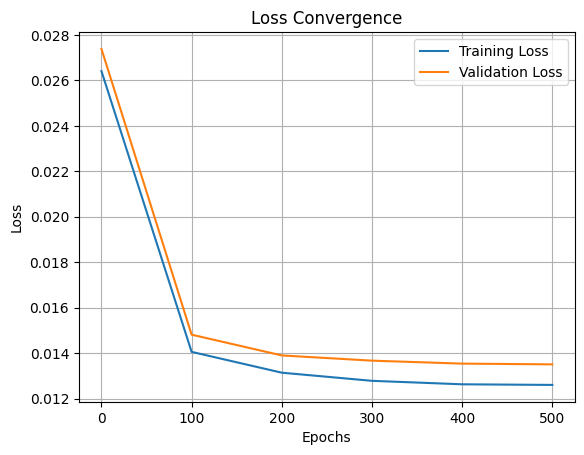

In [16]:
vis_train_loss(train_loss_history_5, val_loss_history_5)

In [17]:
# computing the RMSE
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
def pred_eval(model, X, y, lengths, train_d, test_d, lookback, target_col):
    model.eval()
    with torch.no_grad():
        train_preds = model(X, lengths)
        print("Training RMSE:",root_mean_squared_error(y.flatten().tolist(),train_preds.flatten().tolist()))
        print("Training R2:", r2_score(y.flatten().tolist(),train_preds.flatten().tolist()))
        X_test = []
        y_test = []
        lengths_test = []
        for count, (location_id, test_values, scaler) in enumerate(test_d):
            train_values = train_d[count][1]
            X_test.append(train_values[-lookback:])
            y_test.append(test_values[:,target_col])
            # Append the actual lengths (just like the training phase)
            lengths_test.append(len(train_values[-lookback:]))  
        X_test = torch.Tensor(np.array(X_test)) 
        y_test = torch.Tensor(np.array(y_test))
        lengths_test = torch.Tensor(lengths_test).long()
        test_preds = model(X_test,lengths_test)
        #print(y_test.flatten().tolist())
        #print(test_preds.flatten().tolist())
        print("Test RMSE:",root_mean_squared_error(y_test.flatten().tolist(),test_preds.flatten().tolist()))
        print("Test R2:", r2_score(y_test.flatten().tolist(),test_preds.flatten().tolist()))
        plt.figure(figsize=(10, 6))
        plt.plot(y_test.flatten().tolist(), label="Expected Value")
        plt.plot(test_preds.flatten().tolist(), label="Predicted Value")
        plt.grid()
        plt.legend(fontsize=10)
        plt.tight_layout()
        plt.show()


Training RMSE: 0.11305217503112933
Training R2: 0.5355503644594537
Test RMSE: 0.12887532394977252
Test R2: 0.25743629086187814


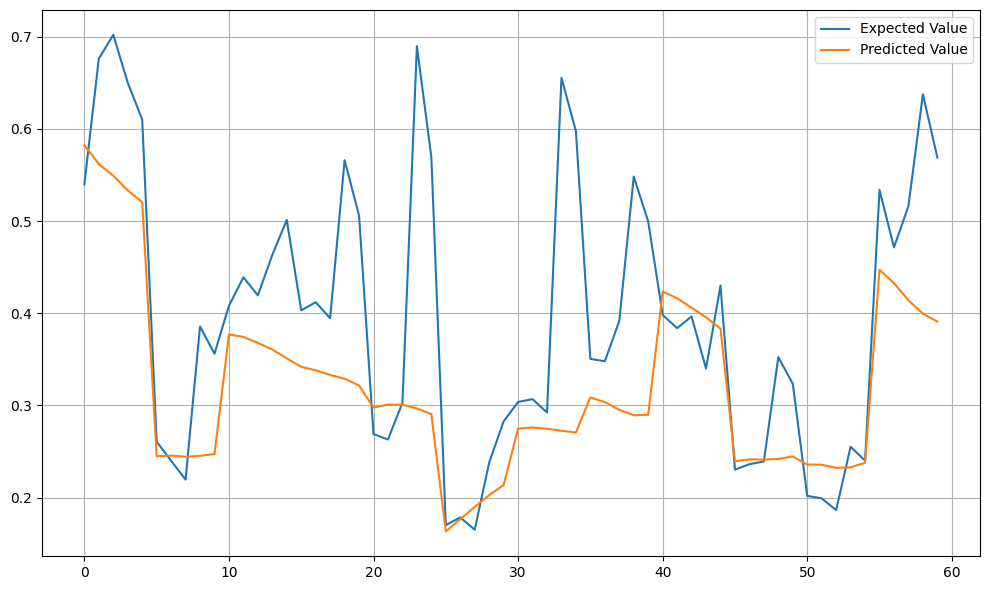

In [18]:
lookback = 5
target_col = 0
pred_eval(model_lstm_5, X_5, y_5, lenghts_5, train_d_5, test_d_5, lookback, target_col)

**LSTM model with Lookback=10**

In [19]:
# another Univariative LSTM mode with changed parameter
lookback = 10
test_steps = 5
target_col = 0
X_10, y_10, lenghts_10, train_d_10, test_d_10 = data_prep(sample_paddock_data,['TSDM'],lookback,test_steps, target_col)

print("Shape of input data after sequence creation:", X_10.shape)
print("Shape of targets after sequence creation:", y_10.shape)

Shape of input data after sequence creation: torch.Size([2220, 10, 1])
Shape of targets after sequence creation: torch.Size([2220, 5])


In [20]:
num_features = X_10.shape[2]
hidden_layer_size = 16
output_size = test_steps
num_layers = 2
dropout_prob = 0.2
model_lstm_10 = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)

In [21]:
print(model_lstm_10)

MyLSTMNet(
  (lstm): LSTM(1, 16, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=16, out_features=5, bias=True)
)


In [22]:
n_epochs = 501
lr = 0.001
train_loss_history_10,val_loss_history_10, model_lstm_10 = train_predict_model(model_lstm_10, n_epochs, 
                                                                            lr, X_10, y_10, lenghts_10,
                                                                            validation_split=0.2)

The model has 3,477 trainable parameters
Epoch 1: train loss 0.0277, val loss 0.0301
Epoch 101: train loss 0.0128, val loss 0.0136
Epoch 201: train loss 0.0122, val loss 0.0136
Epoch 301: train loss 0.0112, val loss 0.0124
Epoch 401: train loss 0.0099, val loss 0.0117
Epoch 501: train loss 0.0083, val loss 0.0116


In [23]:
def vis_train_loss(train_loss_history, val_loss_history):
    epochs = range(0, n_epochs, 100) 
    plt.plot(epochs, train_loss_history, label='Training Loss')
    plt.plot(epochs, val_loss_history, label='Validation Loss')  # <-- add this line
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Convergence')
    plt.legend()
    plt.grid()
    plt.show()

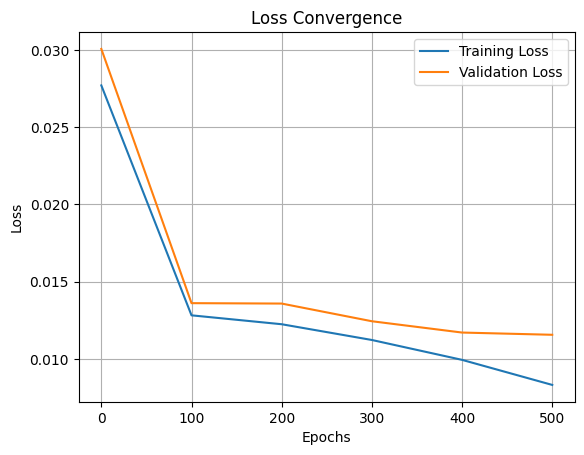

In [24]:
vis_train_loss(train_loss_history_10, val_loss_history_10)

Training RMSE: 0.09468088020081925
Training R2: 0.6742342999972069
Test RMSE: 0.1179775898462167
Test R2: 0.37770942982664435


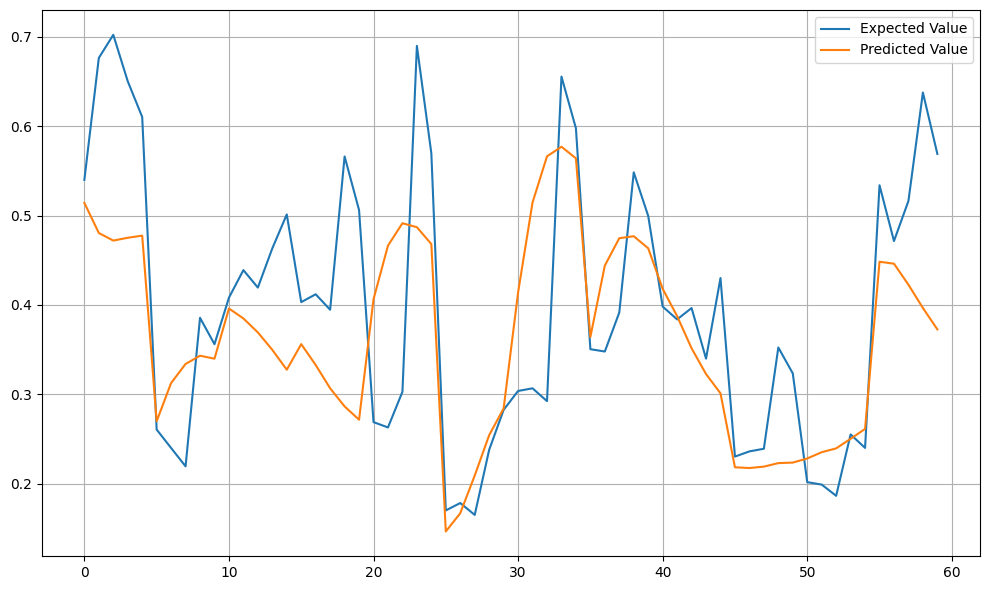

In [25]:
lookback = 10
target_col = 0
pred_eval(model_lstm_10, X_10, y_10, lenghts_10, train_d_10, test_d_10, lookback, target_col)

**Multivariate LSTM model**

Shape of input data after sequence creation: torch.Size([2220, 5, 8])
Shape of targets after sequence creation: torch.Size([2220, 5])
The model has 3,925 trainable parameters
Epoch 1: train loss 0.0265, val loss 0.0258
Epoch 101: train loss 0.0089, val loss 0.0094
Epoch 201: train loss 0.0063, val loss 0.0071
Epoch 301: train loss 0.0054, val loss 0.0063
Epoch 401: train loss 0.0045, val loss 0.0056
Epoch 501: train loss 0.0039, val loss 0.0051


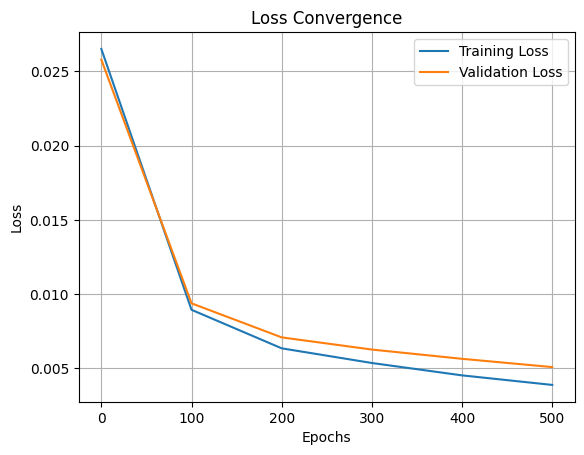

Training RMSE: 0.06421158962781834
Training R2: 0.8501669483377264
Test RMSE: 0.1223746009941368
Test R2: 0.33045964530307204


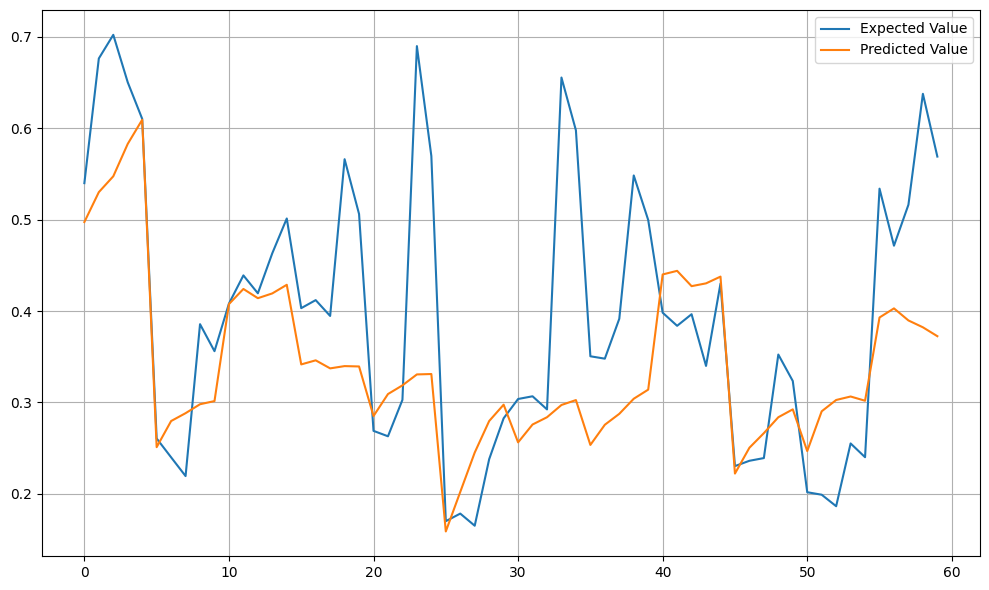

In [26]:
# Look back is set to 5
lookback = 5
test_steps = 5
target_col = 0
X_5_mv, y_5_mv, lenghts_5_mv, train_d_5_mv, test_d_5_mv = data_prep(sample_paddock_data,['TSDM', '15D_AVG_DAILY_RAIN',
       '15D_AVG_MAX_TEMP', '15D_AVG_MIN_TEMP', '15D_AVG_RH_TMAX',
       '15D_AVG_RH_TMIN', '15D_AVG_EVAP_SYN', '15D_AVG_RADIATION'],
                                                                    lookback,test_steps, target_col)

print("Shape of input data after sequence creation:", X_5_mv.shape)
print("Shape of targets after sequence creation:", y_5_mv.shape)

num_features = X_5_mv.shape[2]
hidden_layer_size = 16
output_size = test_steps
n_epochs = 501
lr = 0.001
num_layers = 2
dropout_prob = 0.2

model_lstm_5_mv = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)
train_loss_history_5_mv,val_loss_history_5_mv, model_lstm_5_mv = train_predict_model(model_lstm_5_mv, 
                                                                                     n_epochs, lr, X_5_mv, 
                                                                                     y_5_mv, lenghts_5_mv,
                                                                                     validation_split=0.2)
vis_train_loss(train_loss_history_5_mv, val_loss_history_5_mv)
pred_eval(model_lstm_5_mv, X_5_mv, y_5_mv, lenghts_5_mv, train_d_5_mv, test_d_5_mv, lookback, target_col)

Shape of input data after sequence creation: torch.Size([2220, 10, 8])
Shape of targets after sequence creation: torch.Size([2220, 5])
The model has 1,749 trainable parameters
Epoch 1: train loss 0.0262, val loss 0.0264
Epoch 101: train loss 0.0081, val loss 0.0084
Epoch 201: train loss 0.0055, val loss 0.0061
Epoch 301: train loss 0.0046, val loss 0.0053
Epoch 401: train loss 0.0039, val loss 0.0047
Epoch 501: train loss 0.0038, val loss 0.0047


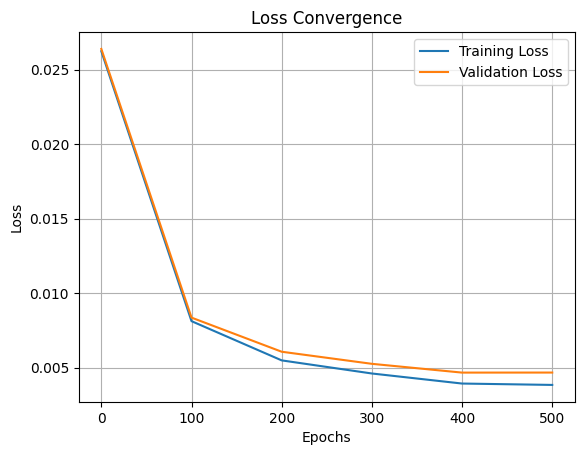

Training RMSE: 0.0633576479326577
Training R2: 0.8541256699409174
Test RMSE: 0.09084997018831162
Test R2: 0.6309852220317642


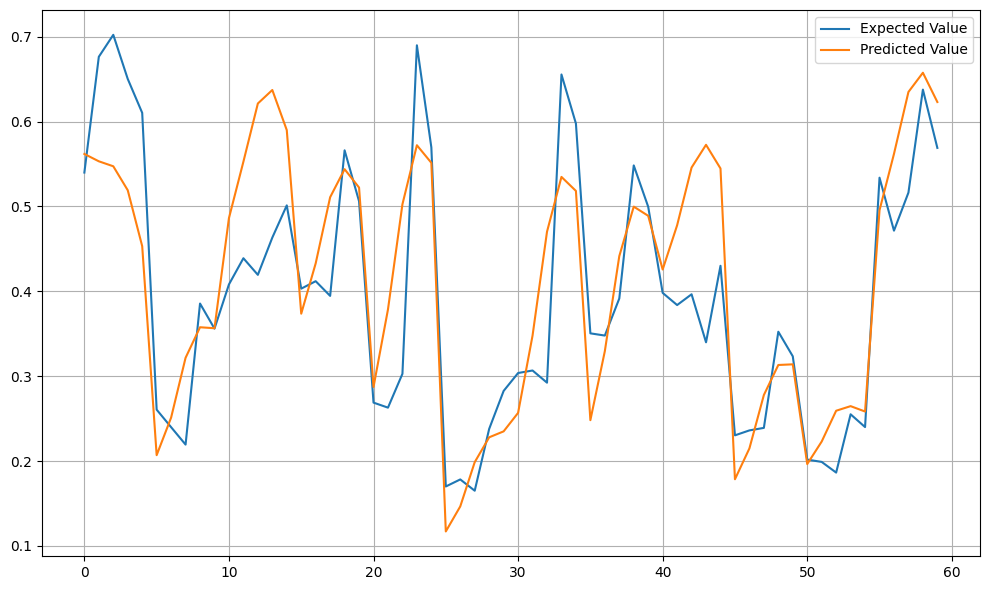

In [27]:
# your code here
lookback = 10
test_steps = 5
target_col = 0
X_10_mv, y_10_mv, lenghts_10_mv, train_d_10_mv, test_d_10_mv = data_prep(sample_paddock_data,['TSDM', '15D_AVG_DAILY_RAIN',
       '15D_AVG_MAX_TEMP', '15D_AVG_MIN_TEMP', '15D_AVG_RH_TMAX',
       '15D_AVG_RH_TMIN', '15D_AVG_EVAP_SYN', '15D_AVG_RADIATION'],
                                                                         lookback,test_steps, target_col)
print("Shape of input data after sequence creation:", X_10_mv.shape)
print("Shape of targets after sequence creation:", y_10_mv.shape)

num_features = X_10_mv.shape[2]
hidden_layer_size = 16
output_size = test_steps
n_epochs = 501
lr = 0.001
num_layers = 1
dropout_prob = 0.2
model_lstm_10_mv = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)

train_loss_history_10_mv,val_loss_history_10_mv, model_lstm_10_mv = train_predict_model(model_lstm_10_mv, n_epochs, 
                                                                                        lr, X_10_mv, y_10_mv, 
                                                                                        lenghts_10_mv,
                                                                                        validation_split=0.2)

vis_train_loss(train_loss_history_10_mv, val_loss_history_10_mv)

pred_eval(model_lstm_10_mv, X_10_mv, y_10_mv, lenghts_10_mv, train_d_10_mv, test_d_10_mv, lookback, target_col)

Shape of input data after sequence creation: torch.Size([2220, 185, 8])
Shape of targets after sequence creation: torch.Size([2220, 5])
The model has 1,749 trainable parameters
Epoch 1: train loss 0.0257, val loss 0.0261
Epoch 101: train loss 0.0062, val loss 0.0070
Epoch 201: train loss 0.0050, val loss 0.0058
Epoch 301: train loss 0.0039, val loss 0.0046
Epoch 401: train loss 0.0036, val loss 0.0041
Epoch 501: train loss 0.0033, val loss 0.0039


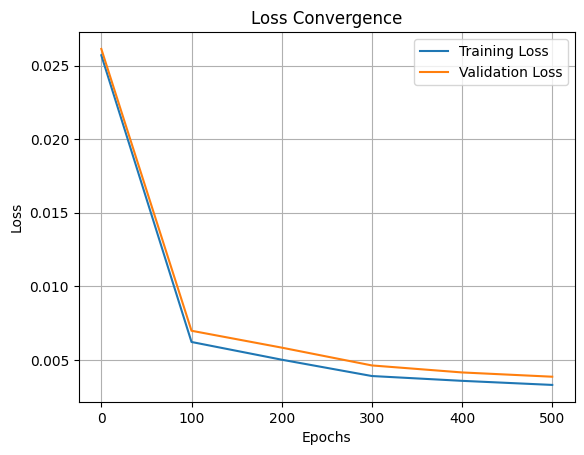

Training RMSE: 0.05841683027280579
Training R2: 0.8759899854579011
Test RMSE: 0.08735586187327737
Test R2: 0.6588241467802234


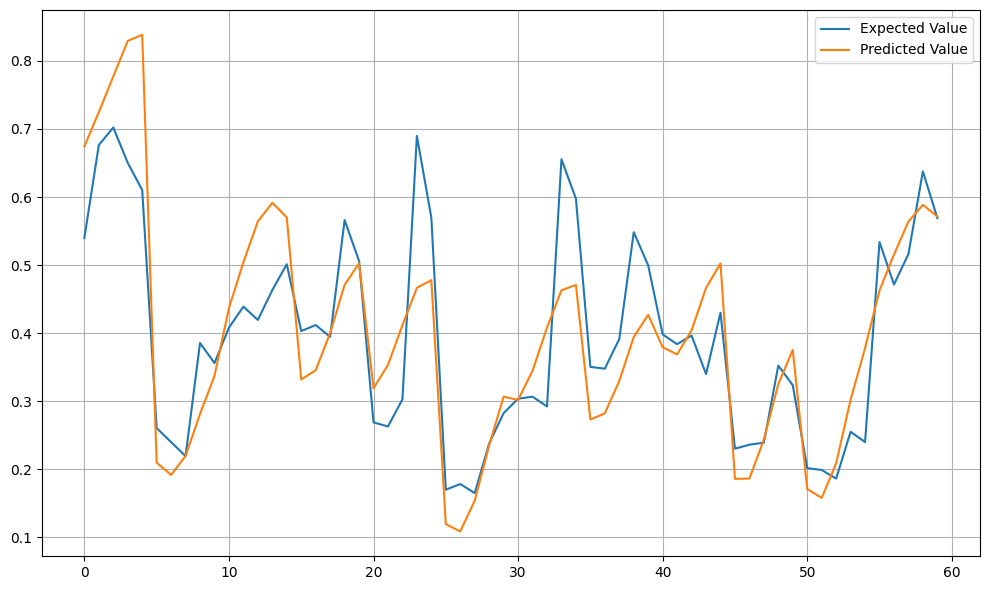

In [28]:
lookback = 0 # Means no restriction of lookback
target_col = 0
X_f, y_f,lengths_f, train_d_f, test_d_f = data_prep(sample_paddock_data,['TSDM', '15D_AVG_DAILY_RAIN',
       '15D_AVG_MAX_TEMP', '15D_AVG_MIN_TEMP', '15D_AVG_RH_TMAX',
       '15D_AVG_RH_TMIN', '15D_AVG_EVAP_SYN', '15D_AVG_RADIATION'],lookback,test_steps, target_col)

print("Shape of input data after sequence creation:", X_f.shape)
print("Shape of targets after sequence creation:", y_f.shape)

num_features = X_f.shape[2]
hidden_layer_size = 16
output_size = test_steps
n_epochs = 501
lr = 0.001
num_layers = 1
dropout_prob = 0.2
model_lstm_f = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)

train_loss_history_f,val_loss_history_f,model_lstm_f = train_predict_model(model_lstm_f, n_epochs, 
                                                                           lr, X_f, y_f, lengths_f, 
                                                                           validation_split=0.2)

vis_train_loss(train_loss_history_f, val_loss_history_f)

pred_eval(model_lstm_f, X_f, y_f, lengths_f, train_d_f, test_d_f, lookback, target_col)

# Task 4: Hydrogen Tweet Classification with BERT